In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import pypsa
import yaml

### Scenario selection

In [2]:
PREFIX = "/mnt/e/H2GMA/Github/Europe/pypsa-eur/"

In [3]:
OUTPUT = PREFIX + "results/myopic-martavp-2025-2050-5-steps-all-sectors/figures/comp/"

In [4]:
# Specify the scenario name and the path here

# Nice comparison
# scenarios = {#"0": PREFIX + f"results/nz_2030_exp/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2030_0.071_AB_0export.nc",
#             "0": PREFIX + f"results/nz_2035_exp/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_0export.nc",
#             "14": PREFIX + f"results/nz_2035_exp/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_14export.nc",
#             "22": PREFIX + f"results/nz_2035_exp/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_22export.nc",
# }

# scenarios = {#"0": PREFIX + f"results/nz_2030_exp/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2030_0.071_AB_0export.nc",
#             "0": PREFIX + f"results/nz_2035_oldCnewW/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_0export.nc",
#             "10": PREFIX + f"results/nz_2035_oldCnewW/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_10export.nc",
#             "20": PREFIX + f"results/nz_2035_oldCnewW/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_20export.nc",
#             "100": PREFIX + f"results/nz_2035_oldCnewW/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_100export.nc",
# }

scenarios = {#"0": PREFIX + f"results/nz_2030_exp/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2030_0.071_AB_0export.nc",
            "2025": PREFIX + f"results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2025.nc",
            "2030": PREFIX + f"results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2030.nc",
            "2035": PREFIX + f"results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2035.nc",
            "2040": PREFIX + f"results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2040.nc",
            "2045": PREFIX + f"results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2045.nc",
            "2050": PREFIX + f"results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2050.nc",}


# Transport scenarios; add full path in order to work
# scenarios = {"10": "nz_nosmr",
#         "15": "nz_ts15",
#         "25": "nz_ts25",
#        }

# 2030-2050 scenarios; add full path in order to work
# scenarios = {"2030": "nz_nosmr",
#         "2050": "nz_2050_cap",
#        }

### Settings

In [5]:
tech_colors = PREFIX + "config/tech_colors.yaml"

In [6]:
threshold_dispatch = 1e6 # 4 TWh

In [7]:
xlabel = "Hydrogen export in TWh" #"EV share in %" for transport scenarios
plotname = "exportquan" #"ev_share" for transport scenarios; "2030-2050cap" for 2030-2050 scenarios

### Data preparation

In [8]:
def load_config(config):
    with open(config, 'r') as stream:
        try:
            config = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return config

### Dispatch data preparation

In [9]:
for sc in scenarios:
    print(sc)
    print(scenarios[sc])

2025
/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2025.nc
2030
/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2030.nc
2035
/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2035.nc
2040
/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2040.nc
2045
/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2045.nc
2050
/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic-martavp-2025-2050-5-steps-all-sectors/postnetworks/base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2050.nc


In [10]:
def get_res_share(dispatch, threshold_dispatch_sum):

    res_techs = [
    "Geothermal",
    "Offshore Wind (AC)",
    "Offshore Wind (DC)",
    "Onshore Wind",
    "Run of River",
    "Solar",
    "Reservoir & Dam",
    ]

    fossil_techs = [
        "Coal",
        "Combined-Cycle Gas",
        "Open-Cycle Gas",
        "urban central gas CHP",
        "Oil",
        "urban central solid biomass CHP CC" # really?
    ]

    dispatch = dispatch.T

    re = dispatch[dispatch.index.isin(res_techs)].sum().values[0]
    fossil = dispatch[dispatch.index.isin(fossil_techs)].sum().values[0]

    # Check, if re + fossil = total dispatch - threshold
    if abs(dispatch.sum().values[0] - threshold_dispatch_sum - re - fossil) > 1000:
        raise ValueError("Sum of dispatches does not match threshold dispatch sum. RE: " + str(re/1e6) + " Fossil: " + str(fossil/1e6) + " Total: " + str(dispatch.sum().values[0]/1e6 - threshold_dispatch_sum/1e6))

    res_share = re / (re + fossil)


    return res_share

In [11]:
def get_emissions(dispatch):

    emissions = dispatch.T.loc[["Coal", "Combined-Cycle Gas"]].iloc[:,0].values * n.carriers.loc[["coal", "CCGT"], "co2_emissions"].values * (1/n.generators.groupby("carrier")["efficiency"].mean().loc[["coal", "CCGT"]].values)

    emissions = emissions.sum() / 1e6 # in MtCO2
    
    return emissions.sum()

In [12]:
def get_dispatch(threshold_dispatch, show_demand=True):
    """Get dispatch
    """

    dispatch_all = pd.DataFrame()
    res_share_all = pd.DataFrame()
    emissions_all = pd.DataFrame()

    for sc in scenarios:

        n = pypsa.Network(scenarios[sc])

        dispatch = n.statistics.dispatch(bus_carrier="AC")[n.statistics.dispatch(bus_carrier="AC") > 0]
        threshold_dispatch_sum = dispatch[dispatch < threshold_dispatch].sum()
        dispatch = dispatch[dispatch > threshold_dispatch]
        dispatch = pd.DataFrame(dispatch.droplevel(0)).T
        dispatch[f"(Dispatch < {threshold_dispatch/1e6} TWh thres.)"] = threshold_dispatch_sum

        dispatch.index = [sc]

        dispatch_all = pd.concat([dispatch_all, dispatch], axis=0) #, ignore_index=True)
        res_share_all = pd.concat([res_share_all, pd.DataFrame([get_res_share(dispatch, threshold_dispatch_sum)], index=[sc])], axis=0)
        #emissions_all = pd.concat([emissions_all, pd.DataFrame([get_emissions(dispatch)], index=[sc])], axis=0)

        

    if show_demand == "bar":
        dispatch_demand = n.statistics.dispatch(bus_carrier="AC")[n.statistics.dispatch(bus_carrier="AC") < 0]
        ely_electricity = dispatch_demand.droplevel(0).loc["H2 Electrolysis"].sum() * (-1)
        total_demand = dispatch_demand.sum() * (-1)
        other_demand = total_demand - ely_electricity
        dispatch_all.loc["Demand", "H2 Electrolysis electricity"] = ely_electricity
        dispatch_all.loc["Demand", "Domestic electricity"] = other_demand
        
    elif show_demand == "line":
        dispatch_demand = n.statistics.dispatch(bus_carrier="AC")[n.statistics.dispatch(bus_carrier="AC") < 0]
        ely_electricity = dispatch_demand.droplevel(0).loc["H2 Electrolysis"].sum() * (-1)
        total_demand = dispatch_demand.sum() * (-1)
        other_demand = total_demand - ely_electricity
        dispatch_all.loc[:, "H2 Electrolysis electricity"] = ely_electricity
        dispatch_all.loc[:, "Domestic electricity"] = other_demand
        
    
    return dispatch_all, res_share_all, emissions_all

In [ ]:
dispatch, res_share, emissions = get_dispatch(threshold_dispatch, show_demand=False)

INFO:pypsa.io:Imported network base_s_39_lvopt__144H-T-H-B-I-A-cb25.7ex0_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


AttributeError: 'StatisticsAccessor' object has no attribute 'dispatch'

In [ ]:
dispatch

NameError: name 'dispatch' is not defined

### Plot data

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/e/H2GMA/Github/Europe/pypsa-eur/config/tech_colors.yaml'

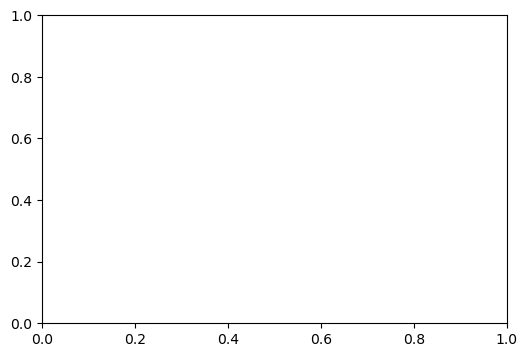

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

# Get colors from yaml defined in tech_colors
colors = load_config(tech_colors)["tech_colors"]

# Sort columns by highest value in first row, and then the preferred order
dispatch_sorted = dispatch[dispatch.iloc[-1].sort_values(ascending=False).index]
preferred_order = ["Solar", "Onshore Wind", "Reservoir & Dam"]
dispatch_sorted = dispatch_sorted[preferred_order + [col for col in dispatch_sorted.columns if col not in preferred_order]]

dispatch_twh = dispatch_sorted / 1e6 # convert to TWh

dispatch_twh.plot.bar(ax=ax, stacked=True, alpha=0.8, color=colors)

plt.xlabel(xlabel)
plt.ylabel("Dispatch in TWh")
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
#plt.ylim(0, 250)

plt.grid(axis='y', alpha=0.5) 

fig.savefig(OUTPUT + plotname + f".pdf", bbox_inches="tight")
fig.savefig(OUTPUT + plotname + f".png", bbox_inches="tight")

### Additional analysis (test field)

In [ ]:
res_share

NameError: name 'res_share' is not defined

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning:

backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning:

backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning:

backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.



NameError: name 'res_share' is not defined

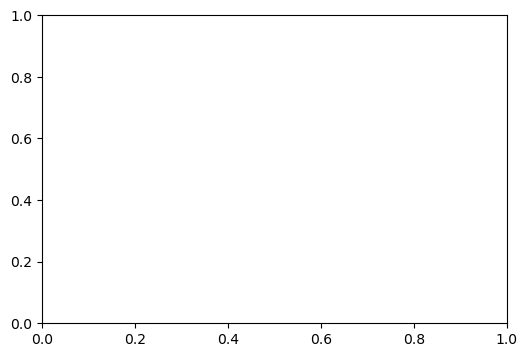

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

res_share.mul(100).plot.bar(ax=ax, color="grey", alpha=0.8)

plt.xlabel("Hydrogen export in TWh")
plt.ylabel("RES Share in %")

# handles, labels = ax.get_legend_handles_labels()
# ax.legend(reversed(handles), reversed(labels), loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.grid(axis='y', alpha=0.5) 


### emissions

In [ ]:
n = pypsa.Network(PREFIX + f"results/nz_2035_oldCnewW/postnetworks/ccl/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_30export.nc")

Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_AB_30export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [ ]:
dispatch

carrier,Coal,Combined-Cycle Gas,Geothermal,Onshore Wind,Run of River,Solar,Reservoir & Dam,urban central gas CHP,(Dispatch < 1.0 TWh thres.),Open-Cycle Gas,urban central solid biomass CHP CC
0,3.504976e+06,6.341128e+06,9.810633e+06,9.557812e+06,2.782138e+06,1.326100e+07,3.252565e+07,1.244008e+06,779044.689690,NaN,NaN
5,3.817137e+06,4.084792e+06,9.810980e+06,1.647131e+07,2.782929e+06,1.694481e+07,3.252662e+07,NaN,354468.328470,NaN,NaN
10,3.871939e+06,3.011214e+06,9.810907e+06,2.287335e+07,2.782845e+06,1.884832e+07,3.252646e+07,NaN,243736.743394,NaN,NaN
15,3.924076e+06,7.703709e+06,9.810713e+06,2.331937e+07,2.782333e+06,2.077096e+07,3.252606e+07,NaN,240217.984262,NaN,NaN
20,4.081936e+06,1.236055e+07,9.810857e+06,2.395193e+07,2.782660e+06,2.079003e+07,3.252633e+07,1.703035e+06,153210.050980,NaN,NaN
25,4.237385e+06,1.459963e+07,9.811066e+06,2.444071e+07,2.783126e+06,2.079929e+07,3.252682e+07,2.354840e+06,438981.338876,3.266484e+06,NaN
100,NaN,1.601001e+07,9.811199e+06,2.489223e+07,2.783434e+06,2.075519e+07,3.252717e+07,NaN,756681.084186,1.124910e+08,6.576012e+06


In [ ]:

emissions = dispatch.T.loc[["Coal", "Combined-Cycle Gas"]].iloc[:,0].values * n.carriers.loc[["coal", "CCGT"], "co2_emissions"].values * (1/n.generators.groupby("carrier")["efficiency"].mean().loc[["coal", "CCGT"]].values)


In [ ]:
emissions/ 1e6

array([3.61118744, 2.18659571])

In [ ]:
dispatch.T.iloc[:,0]

carrier
Coal                                  3.504976e+06
Combined-Cycle Gas                    6.341128e+06
Geothermal                            9.810633e+06
Onshore Wind                          9.557812e+06
Run of River                          2.782138e+06
Solar                                 1.326100e+07
Reservoir & Dam                       3.252565e+07
urban central gas CHP                 1.244008e+06
(Dispatch < 1.0 TWh thres.)           7.790447e+05
Open-Cycle Gas                                 NaN
urban central solid biomass CHP CC             NaN
Name: 0, dtype: float64

In [ ]:
n.carriers.loc[["coal", "CCGT"], "co2_emissions"] #.values

Carrier
coal    0.34
CCGT    0.20
Name: co2_emissions, dtype: float64

In [ ]:
n.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
biomass,0.00,#0c6013,Biomass,inf,0.0
oil,0.00,#262626,Oil,inf,0.0
lignite,0.41,#9e5a01,Lignite,inf,0.0
OCGT,0.20,#d35050,Open-Cycle Gas,inf,0.0
coal,0.34,#707070,Coal,inf,0.0
geothermal,0.03,#ba91b1,Geothermal,inf,0.0
nuclear,0.00,#ff9000,Nuclear,inf,0.0
CCGT,0.20,#b20101,Combined-Cycle Gas,inf,0.0
hydro,0.00,#08ad97,Reservoir & Dam,inf,0.0


In [ ]:
dispatch.T.loc[["Coal", "Combined-Cycle Gas"]].iloc[:,0]

carrier
Coal                  3.504976e+06
Combined-Cycle Gas    6.341128e+06
Name: 0, dtype: float64

In [ ]:


emissions = emissions.sum() / 1e6 # in MtCO2


In [ ]:
get_emissions(dispatch)

5.797783152703239

In [ ]:
emissions_dummy = pd.DataFrame([5, 4, 3, 4, 5, 6,10], index=res_share.index)
emissions_dummy

,0
0,5
5,4
10,3
15,4
20,5
25,6
100,10


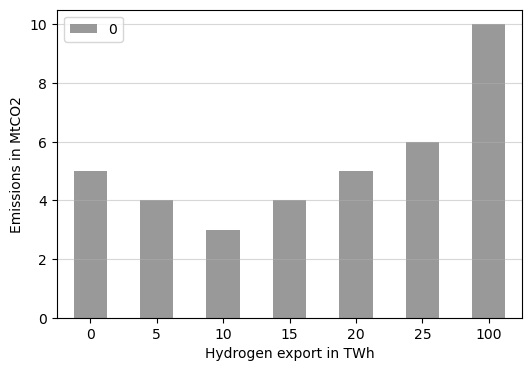

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

emissions_dummy.plot.bar(ax=ax, color="grey", alpha=0.8)

plt.xlabel("Hydrogen export in TWh")
plt.ylabel("Emissions in MtCO2")

# handles, labels = ax.get_legend_handles_labels()
# ax.legend(reversed(handles), reversed(labels), loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
# plt.ylim(0, 100)

plt.grid(axis='y', alpha=0.5) 


In [ ]:
# convert res_share.index.values to float
